In [1]:
%matplotlib inline

import numpy as np
import rebound
import matplotlib.pyplot as plt
import multiprocess as mp
from spock import FeatureClassifier

In [2]:
def wrapRad(theta, k):
    return (theta + k*np.pi) % (2*k*np.pi) - k*np.pi

In [ ]:
def get_sims(xlist, ylist):
    sims = []
    for y in ylist:
        for x in xlist:
            sims.append(make_sim(j1, k1, j2, k2, P1, P2, mu1, mu2, ecc, pomega0, x, y))
    return sims

def get_pars(xlist, ylist):
    pars = []
    for y in ylist:
        for x in xlist:
            pars.append((j1, k1, j2, k2, P1, P2, mu1, mu2, ecc, pomega0, x, y))
    return pars

def get_centered_grid(xlist, ylist, probs):
    # assumes uniformly spaced values in x and y (can have different lengths)
    dx = xlist[1]-xlist[0]
    dy = ylist[1]-ylist[0]

    xgrid = [x - dx/2 for x in xlist] + [xlist[-1]+dx/2]
    ygrid = [y - dy/2 for y in ylist] + [ylist[-1]+dy/2]

    X, Y = np.meshgrid(xgrid, ygrid)
    Z = np.array(probs).reshape(len(ylist),len(xlist))

    return X,Y,Z

In [ ]:
def make_sim(j1, k1, j2, k2, P1, P2, mu1, mu2, ecc, pomega0, phi0, P0):
    lambda0 = phi0/j1

    # start simulation
    sim = rebound.Simulation()
    sim.units = ('yr', 'AU', 'Msun')

    # add star, planet 1, planet 2
    sim.add(m=1.)
    sim.add(m=mu1, P=P1, l=-np.pi/(j1-k1))
    sim.add(m=mu2, P=P2, l=-(k2+1)%2*np.pi/(j2+k2))
    ps = sim.particles
    ps[1].r = ps[1].a*(ps[1].m/3/ps[0].m)**(1/3)
    ps[2].r = ps[2].a*(ps[2].m/3/ps[0].m)**(1/3)

    # add test particle
    sim.add(P=P0, l=lambda0, e=ecc, pomega=pomega0)
    sim.move_to_com()
    sim.integrator = "whfast"
    sim.dt = sim.particles[1].P/12
    sim.collision = "direct"
    return sim

In [8]:
pomega0 = 0
j1, k1, j2, k2 = 3, 1, 3, 1

P1, P2 = 1, 2.04 # MMRs on top of each other at 3/2*4/3 = 2
mu1, mu2 = 3e-5, 3e-5#, P1, P2 = param2OE((r, nu, epsilon1, epsilon2), (ecc, P1, j1, k1, k2))
ecc = 0.05

In [9]:
phi0s = np.linspace(-np.pi, np.pi, 30)
P0s = np.linspace(1.47, 1.56, 30)

In [10]:
%%time
model = FeatureClassifier()
sims = get_sims(phi0s, P0s)
probs = model.predict_stable(sims)
np.savetxt('probsFinal.txt', probs)

CPU times: user 10min 23s, sys: 3min 42s, total: 14min 6s
Wall time: 6min 26s


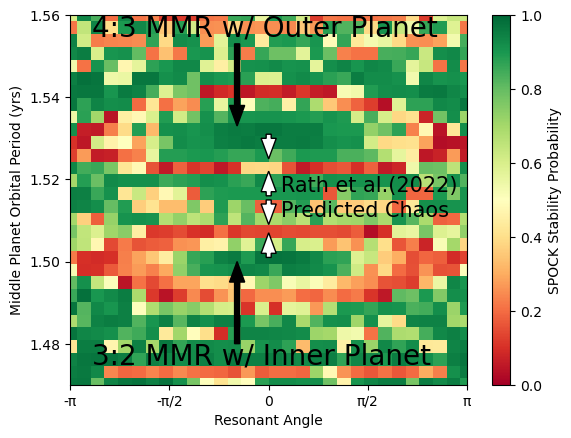

In [ ]:
%matplotlib inline
probs = np.loadtxt('probsFinal.txt')
fig, ax = plt.subplots()
ax.set_xlabel('Resonant Angle')
ax.set_xticks(np.linspace(-np.pi, np.pi, 5), ['-π','-π/2', '0', 'π/2', 'π'])
ax.set_xlim([-np.pi, np.pi])
ax.set_ylim([P0s[0], P0s[-1]])
ax.set_ylabel('Middle Planet Orbital Period (yrs)')

X,Y,Z = get_centered_grid(phi0s, P0s, probs)
im = ax.pcolormesh(X, Y, Z, vmin=0, vmax=1, cmap="RdYlGn", rasterized=True)

cb = plt.colorbar(im, ax=ax)
cb.set_label("SPOCK Stability Probability")

ax.arrow(x=0, y=1.501, dx=0, dy=0.001, width=.08, head_length=0.005, facecolor='white', edgecolor='k')
ax.arrow(x=0, y=1.515, dx=0, dy=-0.001, width=.08, head_length=0.005, facecolor='white', edgecolor='k')
ax.arrow(x=0, y=1.516, dx=0, dy=0.001, width=.08, head_length=0.005, facecolor='white', edgecolor='k')
ax.arrow(x=0, y=1.531, dx=0, dy=-0.001, width=.08, head_length=0.005, facecolor='white', edgecolor='k')
ax.text(0.2, 1.517, "Rath et al.(2022)", fontsize=15)
ax.text(0.2, 1.511, "Predicted Chaos", fontsize=15)
ax.arrow(x=-0.5, y=1.48, dx=0, dy=0.015, width=.08, head_length=0.005, facecolor='black', edgecolor='k')
ax.text(-2.8, 1.475, "3:2 MMR w/ Inner Planet", fontsize=20)
ax.arrow(x=-0.5, y=1.553, dx=0, dy=-0.015, width=.08, head_length=0.005, facecolor='black', edgecolor='k')
ax.text(-2.8, 1.555, "4:3 MMR w/ Outer Planet", fontsize=20)

fig.savefig('rath.pdf', bbox_inches='tight')
plt.show()

# Upping number of phi0s and P0s by 10 each

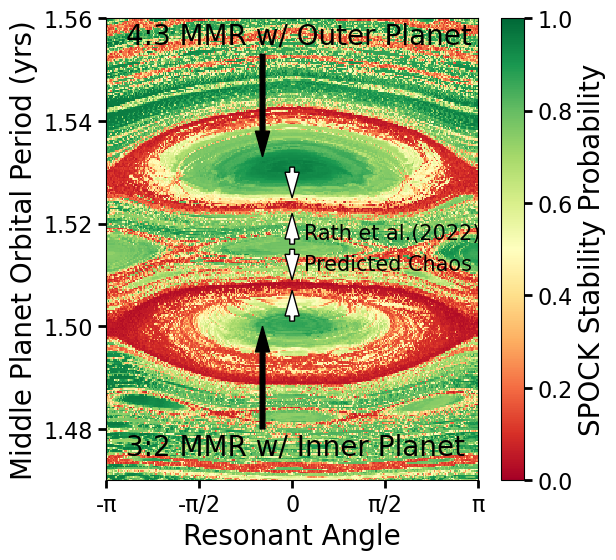

In [ ]:
%matplotlib inline
probs = np.loadtxt('probsFinal.txt')
fig, ax = plt.subplots()
ax.set_xlabel('Resonant Angle')
ax.set_xticks(np.linspace(-np.pi, np.pi, 5), ['-π','-π/2', '0', 'π/2', 'π'])
ax.set_xlim([-np.pi, np.pi])
ax.set_ylim([P0s[0], P0s[-1]])
ax.set_ylabel('Middle Planet Orbital Period (yrs)')

X,Y,Z = get_centered_grid(phi0s, P0s, probs)
im = ax.pcolormesh(X, Y, Z, vmin=0, vmax=1, cmap="RdYlGn", rasterized=True)

cb = plt.colorbar(im, ax=ax)
cb.set_label("SPOCK Stability Probability")

ax.arrow(x=0, y=1.501, dx=0, dy=0.001, width=.08, head_length=0.005, facecolor='white', edgecolor='k')
ax.arrow(x=0, y=1.515, dx=0, dy=-0.001, width=.08, head_length=0.005, facecolor='white', edgecolor='k')
ax.arrow(x=0, y=1.516, dx=0, dy=0.001, width=.08, head_length=0.005, facecolor='white', edgecolor='k')
ax.arrow(x=0, y=1.531, dx=0, dy=-0.001, width=.08, head_length=0.005, facecolor='white', edgecolor='k')
ax.text(0.2, 1.517, "Rath et al.(2022)", fontsize=15)
ax.text(0.2, 1.511, "Predicted Chaos", fontsize=15)
ax.arrow(x=-0.5, y=1.48, dx=0, dy=0.015, width=.08, head_length=0.005, facecolor='black', edgecolor='k')
ax.text(-2.8, 1.475, "3:2 MMR w/ Inner Planet", fontsize=20)
ax.arrow(x=-0.5, y=1.553, dx=0, dy=-0.015, width=.08, head_length=0.005, facecolor='black', edgecolor='k')
ax.text(-2.8, 1.555, "4:3 MMR w/ Outer Planet", fontsize=20)

fig.savefig('rath.pdf', bbox_inches='tight')